# KoalaDrive Graph Piezo  Step-Size Analysis

This notebook analyzes the step-size behavior of a piezo-driven positioning
stage under two experimental conditions:

- **Frequency sweep** — drive frequency varied (100, 50, 25 Hz) at a fixed voltage of 40 V
- **Voltage sweep** — drive voltage varied (40, 30, 20 V) at a fixed frequency of 100 Hz

For each condition, the stage was measured in two mounting **positions**
(`Horizontal` and `Vertical` as `+Z'` and `-Z'`).

From these raw step sizes we derive:
- **Ds** — the displacement-step magnitude as the step size(nm)
- **Asymmetry** — the relative difference between the `+Z'` and `-Z'` step sizes
- **Ratio** — the ratio of `-Z'` to `+Z'` step size

The goal is to understand how frequency and voltage affect step size and
directional asymmetry, and whether the effect differs between the horizontal
and vertical mounting positions.


## 1. Imports and Global Plot Configuration

In [1]:
# --- Standard library ---
# (none required)

# --- Third-party libraries ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

In [2]:
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
plt.rcParams['font.family'] = 'arial'
plt.rcParams['font.size'] = 7
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['ytick.minor.width'] = 0.5
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = [86.0/25.4, 86.0/25.4]

## 2. Data Preparation

In [3]:
# Tidy long-format dataset: one row per (Experiment, Position, Level) combination
raw_records = [
    # Experiment,  Position,     Level(Hz/V), +Z' (nm),            -Z' (nm),            Ds (nm),             Asymmetry,            ratio
    ("Frequency", "Horizontal", 100, 904.9773755656108,  1060.070671378092,  155.09329581248107, 0.07892595606183893, 1.1713780918727916),
    ("Frequency", "Horizontal", 50,  1090.909090909091,  1169.5906432748538, 78.68155236576285,  0.034807149576669784, 1.0721247563352827),
    ("Frequency", "Horizontal", 25,  1132.0754716981132, 1219.5121951219512, 87.43672342383798,  0.03718199608610566, 1.0772357723577235),

    ("Frequency", "Vertical",   100, 462.962962962963,   969.3053311793215,  506.34236821635847, 0.3535248041775456,  2.093699515347334),
    ("Frequency", "Vertical",   50,  993.3774834437087,  1388.888888888889,  395.51140544518023, 0.166023166023166,   1.3981481481481481),
    ("Frequency", "Vertical",   25,  1145.0381679389313, 1428.5714285714287, 283.53326063249733, 0.11016949152542374, 1.2476190476190476),

    ("Voltage",   "Horizontal", 40,  940.4388714733543,  961.5384615384615,  21.099590065107236, 0.011093502377179043, 1.0224358974358974),
    ("Voltage",   "Horizontal", 30,  614.7540983606557,  638.2978723404256,  23.543773979769867, 0.018789144050104442, 1.0382978723404257),
    ("Voltage",   "Horizontal", 20,  292.96875,          326.0869565217391,  33.118206521739125, 0.05349794238683127,  1.1130434782608696),

    ("Voltage",   "Vertical",   40,  462.962962962963,   969.3053311793215,  506.34236821635847, 0.3535248041775456,  2.093699515347334),
    ("Voltage",   "Vertical",   30,  418.99441340782124, 808.6253369272237,  389.6309235194024,  0.3173873045078196,  1.9299191374663072),
    ("Voltage",   "Vertical",   20,  278.8104089219331,  493.4210526315789,  214.61064370964579, 0.2779097387173396,  1.7697368421052628),
]

step_size_df = pd.DataFrame(
    raw_records,
    columns=["Experiment", "Position", "Level", "+Z'", "-Z'", "Ds", "Asymetry", "ratio"],
)

step_size_df


,Experiment,Position,Level,+Z',-Z',Ds,Asymetry,ratio
0,Frequency,Horizontal,100,904.977376,1060.070671,155.093296,0.078926,1.171378
1,Frequency,Horizontal,50,1090.909091,1169.590643,78.681552,0.034807,1.072125
2,Frequency,Horizontal,25,1132.075472,1219.512195,87.436723,0.037182,1.077236
3,Frequency,Vertical,100,462.962963,969.305331,506.342368,0.353525,2.093700
4,Frequency,Vertical,50,993.377483,1388.888889,395.511405,0.166023,1.398148
5,Frequency,Vertical,25,1145.038168,1428.571429,283.533261,0.110169,1.247619
6,Voltage,Horizontal,40,940.438871,961.538462,21.099590,0.011094,1.022436
7,Voltage,Horizontal,30,614.754098,638.297872,23.543774,0.018789,1.038298
8,Voltage,Horizontal,20,292.968750,326.086957,33.118207,0.053498,1.113043
9,Voltage,Vertical,40,462.962963,969.305331,506.342368,0.353525,2.093700


In [4]:
# Split the tidy table into the two experimental subsets used throughout the
# analysis below. Sorting descending reproduces the sweep order used during
# data collection (100 -> 50 -> 25 Hz, 40 -> 30 -> 20 V).
freq_df = (
    step_size_df[step_size_df["Experiment"] == "Frequency"]
    .rename(columns={"Level": "Frequency"})
    .drop(columns="Experiment")
    .sort_values("Frequency", ascending=False)
    .reset_index(drop=True)
)

freq_df

,Position,Frequency,+Z',-Z',Ds,Asymetry,ratio
0,Horizontal,100,904.977376,1060.070671,155.093296,0.078926,1.171378
1,Vertical,100,462.962963,969.305331,506.342368,0.353525,2.093700
2,Horizontal,50,1090.909091,1169.590643,78.681552,0.034807,1.072125
3,Vertical,50,993.377483,1388.888889,395.511405,0.166023,1.398148
4,Horizontal,25,1132.075472,1219.512195,87.436723,0.037182,1.077236
5,Vertical,25,1145.038168,1428.571429,283.533261,0.110169,1.247619


In [5]:
volt_df = (
    step_size_df[step_size_df["Experiment"] == "Voltage"]
    .rename(columns={"Level": "Voltage"})
    .drop(columns="Experiment")
    .sort_values("Voltage", ascending=False)
    .reset_index(drop=True)
)

volt_df

,Position,Voltage,+Z',-Z',Ds,Asymetry,ratio
0,Horizontal,40,940.438871,961.538462,21.099590,0.011094,1.022436
1,Vertical,40,462.962963,969.305331,506.342368,0.353525,2.093700
2,Horizontal,30,614.754098,638.297872,23.543774,0.018789,1.038298
3,Vertical,30,418.994413,808.625337,389.630924,0.317387,1.929919
4,Horizontal,20,292.968750,326.086957,33.118207,0.053498,1.113043
5,Vertical,20,278.810409,493.421053,214.610644,0.277910,1.769737


## 3. Step Size Analysis

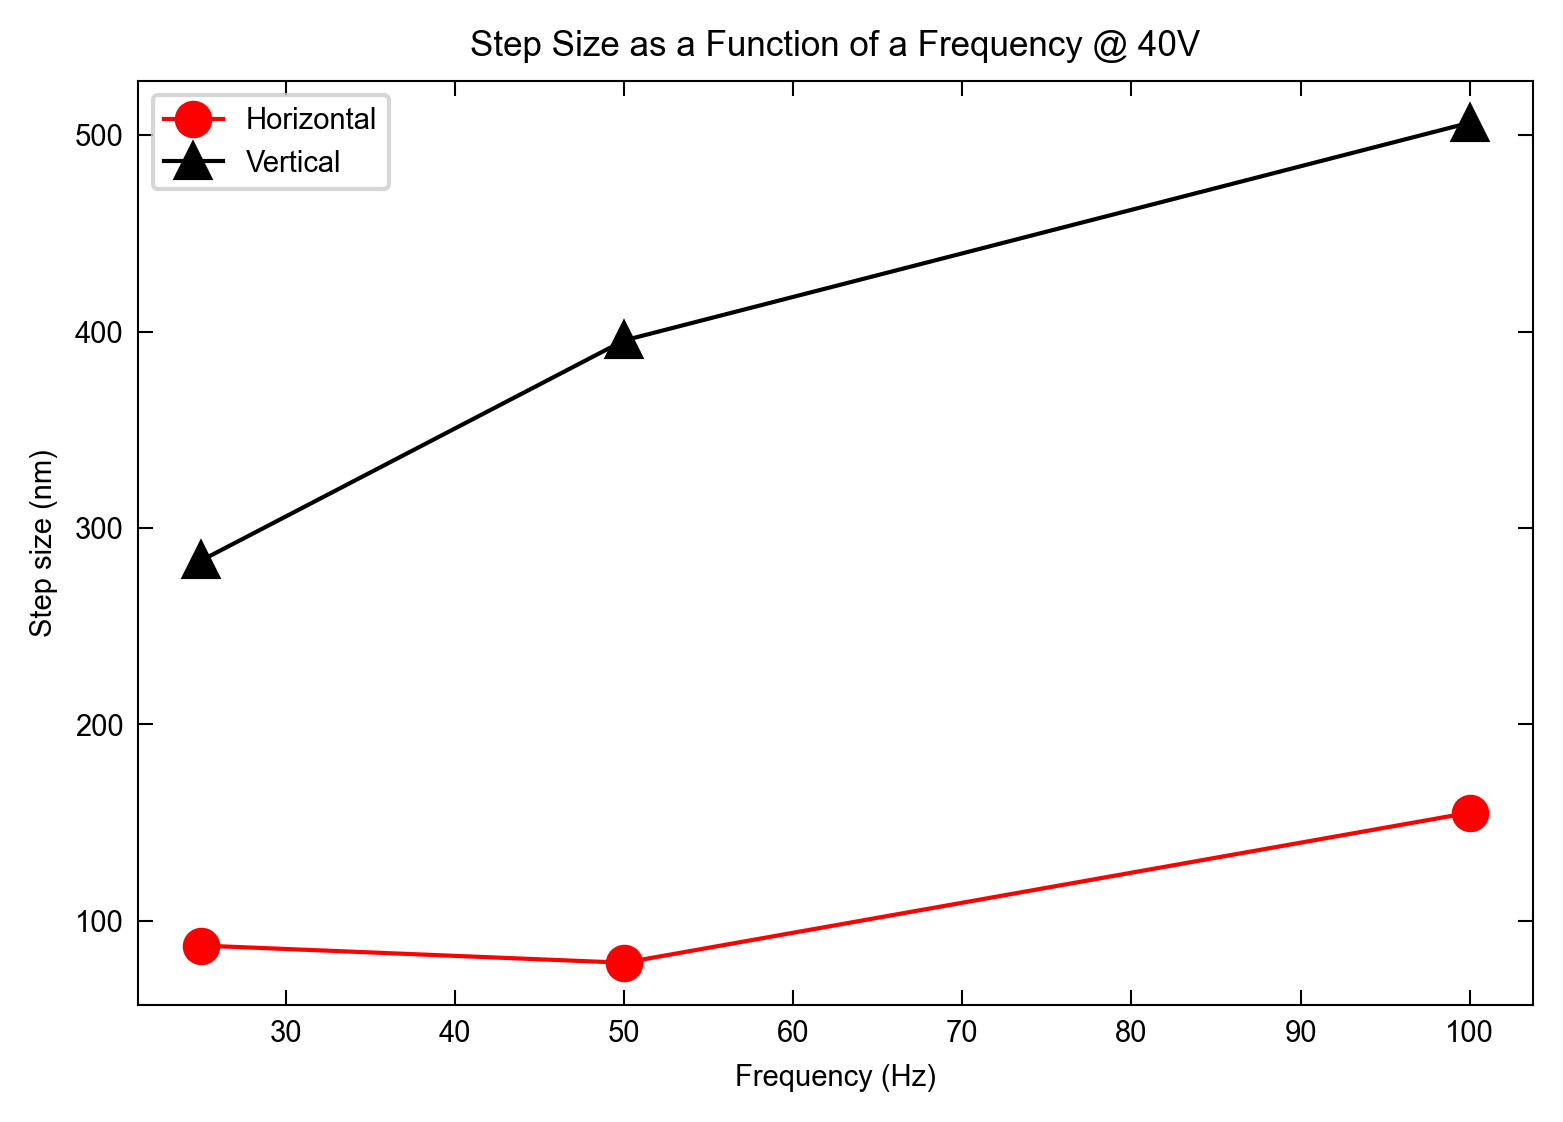

In [6]:
# Re-define data
x1 = [100, 50, 25]
y1 = [155.0932958, 78.68155237, 87.43672342]
x2 = [100, 50, 25]
y2 = [506.3423682, 395.5114054, 283.5332606]

# Create the plot with style similar to provided image
plt.figure(figsize=(6,4))

# Plot first dataset (red upward triangles)
plt.plot(x1, y1, color='red', marker='o', linestyle='-', linewidth=1, markersize=8, label='Horizontal')

# Plot second dataset (black downward triangles)
plt.plot(x2, y2, color='black', marker='^', linestyle='-', linewidth=1, markersize=8, label='Vertical')

# Labels and title
plt.xlabel('Frequency (Hz)')
plt.ylabel('Step size (nm)')
plt.title('Step Size as a Function of a Frequency @ 40V')

# Legend
plt.legend()

# Grid off to match style
plt.grid(False)

# Show plot
plt.show()


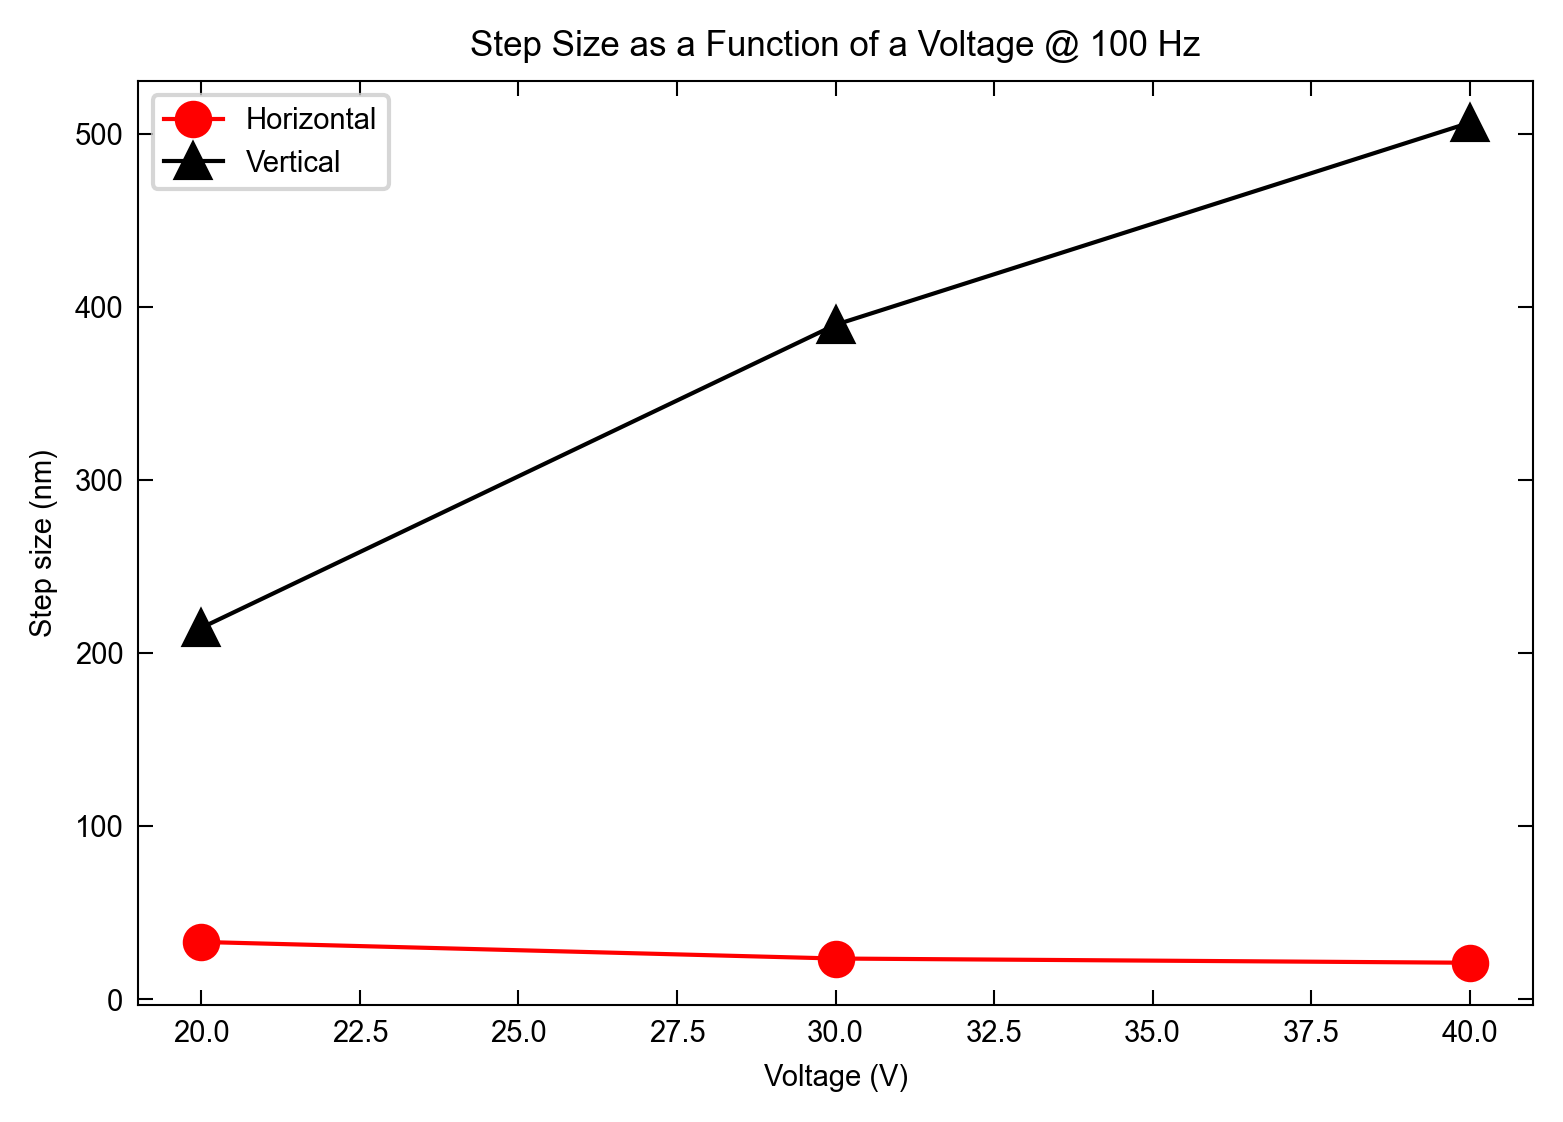

In [7]:
# Re-define data
x = [40, 30, 20]
y1 = [21.09959007, 23.54377398, 33.11820652]
y2 = [506.3423682, 389.6309235, 214.6106437]

# Create the plot with style similar to provided image
plt.figure(figsize=(6,4))

# Plot first dataset (red upward triangles)
plt.plot(x, y1, color='red', marker='o', linestyle='-', linewidth=1, markersize=8, label='Horizontal')

# Plot second dataset (black downward triangles)
plt.plot(x, y2, color='black', marker='^', linestyle='-', linewidth=1, markersize=8, label='Vertical')

# Labels and title
plt.xlabel('Voltage (V)')
plt.ylabel('Step size (nm)')
plt.title('Step Size as a Function of a Voltage @ 100 Hz')

# Legend
plt.legend()

# Grid off to match style
plt.grid(False)

# Show plot
plt.show()


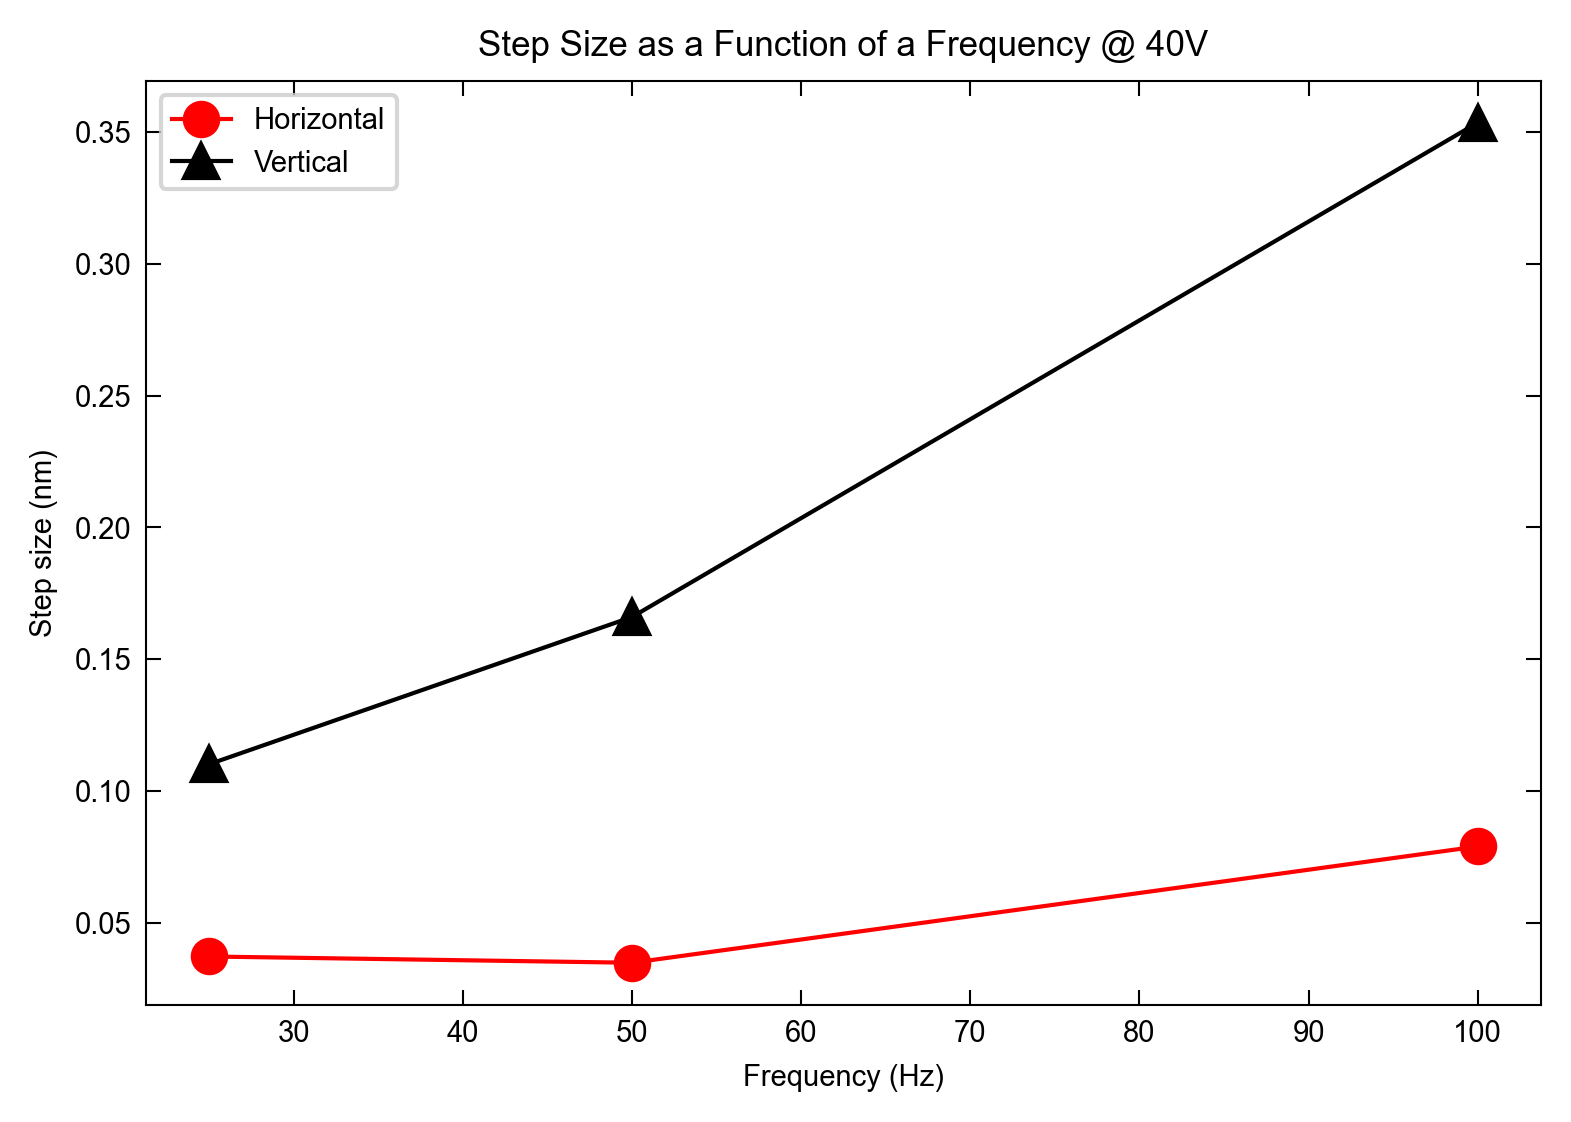

In [8]:
# Re-define data
x = [100, 50, 25]
y1 = [0.078925956, 0.03480715, 0.037181996]
y2 = [0.353524804, 0.166023166, 0.110169492]

# Create the plot with style similar to provided image
plt.figure(figsize=(6,4))

# Plot first dataset (red upward triangles)
plt.plot(x, y1, color='red', marker='o', linestyle='-', linewidth=1, markersize=8, label='Horizontal')

# Plot second dataset (black downward triangles)
plt.plot(x, y2, color='black', marker='^', linestyle='-', linewidth=1, markersize=8, label='Vertical')

# Labels and title
plt.xlabel('Frequency (Hz)')
plt.ylabel('Step size (nm)')
plt.title('Step Size as a Function of a Frequency @ 40V')

# Legend
plt.legend()

# Grid off to match style
plt.grid(False)

# Show plot
plt.show()

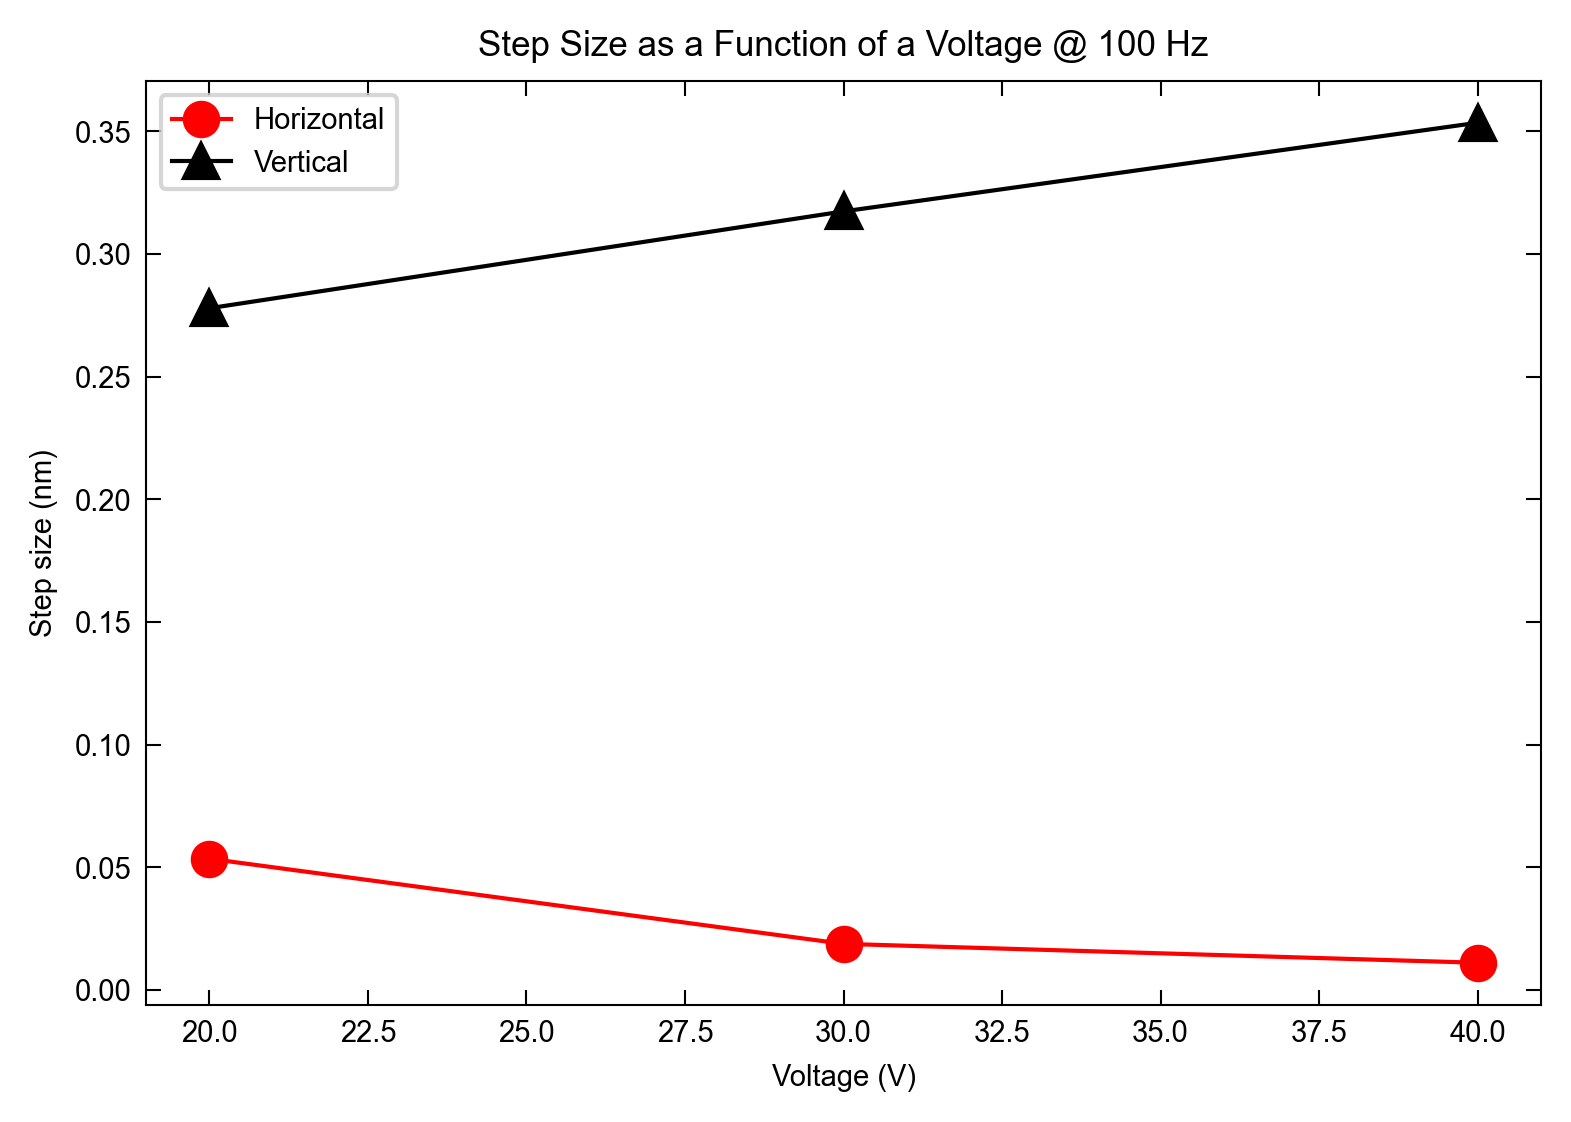

In [9]:
# Re-define data
x = [40, 30, 20]
y1 = [0.011093502, 0.018789144, 0.053497942]
y2 = [0.353524804, 0.317387305, 0.277909739]

# Create the plot with style similar to provided image
plt.figure(figsize=(6,4))

# Plot first dataset (red upward triangles)
plt.plot(x, y1, color='red', marker='o', linestyle='-', linewidth=1, markersize=8, label='Horizontal')

# Plot second dataset (black downward triangles)
plt.plot(x, y2, color='black', marker='^', linestyle='-', linewidth=1, markersize=8, label='Vertical')

# Labels and title
plt.xlabel('Voltage (V)')
plt.ylabel('Step size (nm)')
plt.title('Step Size as a Function of a Voltage @ 100 Hz')

# Legend
plt.legend()

# Grid off to match style
plt.grid(False)

# Show plot
plt.show()


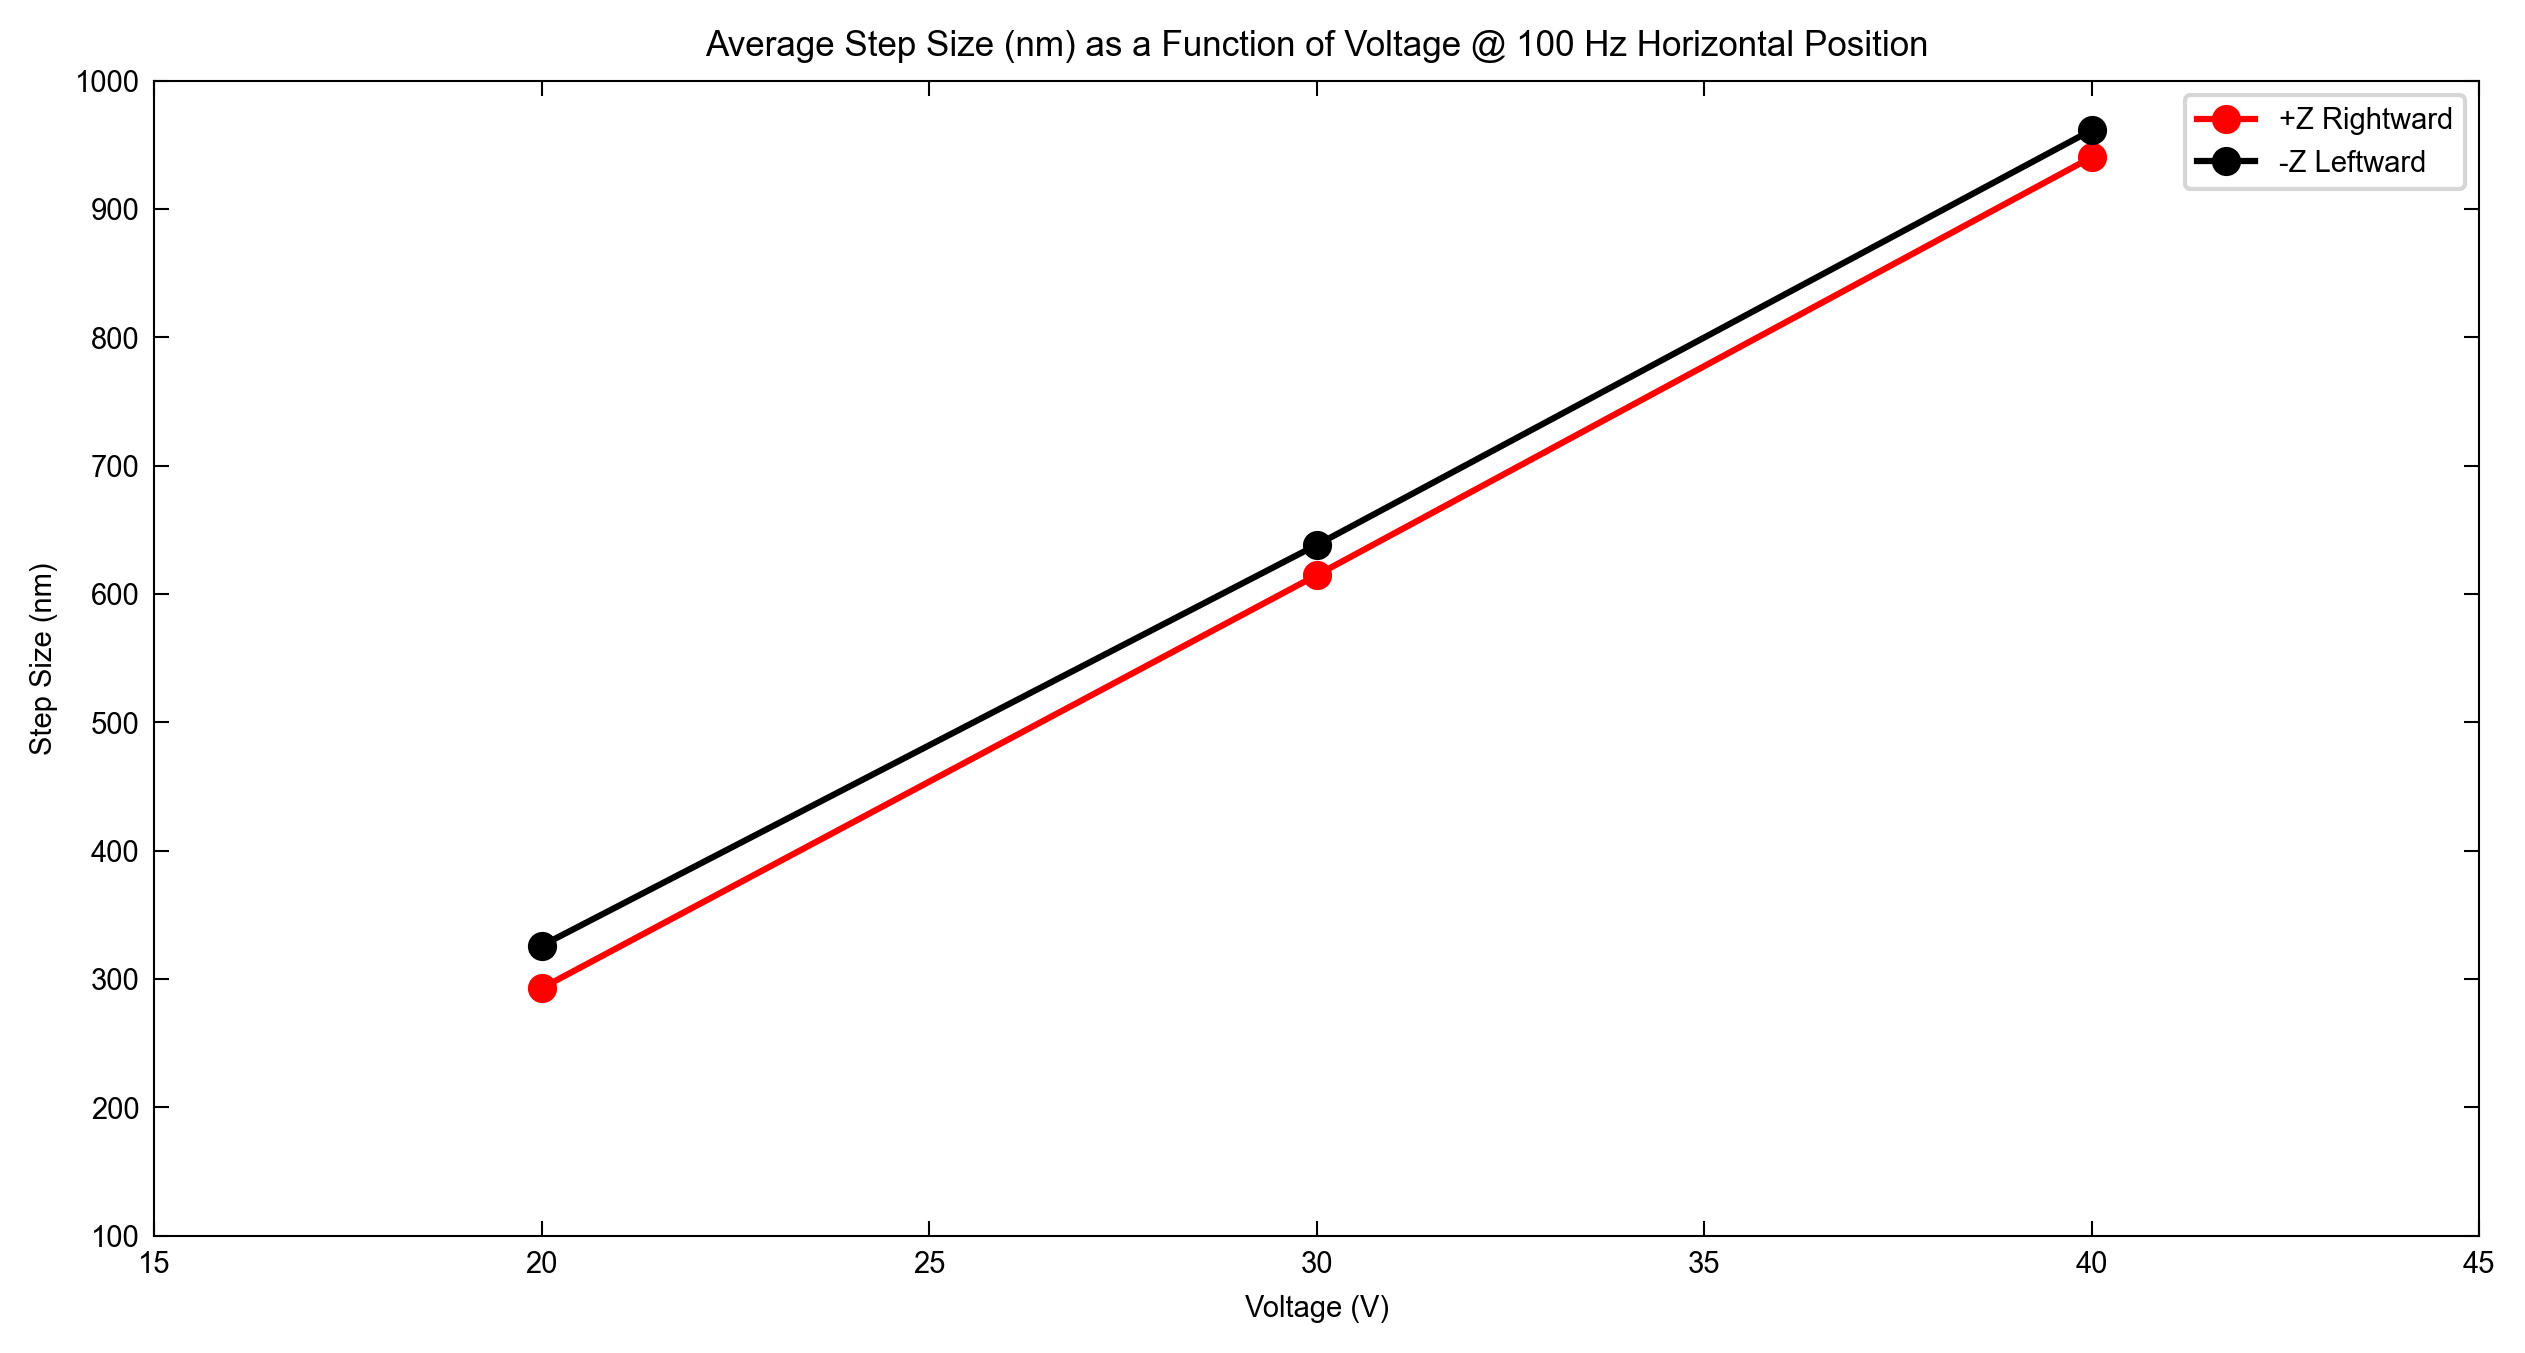

In [10]:
import matplotlib.pyplot as plt

# Data
voltage = [40, 30, 20]
avg_step_plusZ = [940.44, 614.75, 292.97]   # perkiraan dari grafik
avg_step_minusZ = [961.54, 638.30, 326.09]  # perkiraan dari grafik

# Membuat plot
plt.figure(figsize=(10, 5))
plt.plot(voltage, avg_step_plusZ, marker='o', color = 'r', label='+Z Rightward')
plt.plot(voltage, avg_step_minusZ, marker='o', color = 'k', label='-Z Leftward')

# Memberi judul dan label
plt.title('Average Step Size (nm) as a Function of Voltage @ 100 Hz Horizontal Position')
plt.xlabel('Voltage (V)')
plt.ylabel('Step Size (nm)')


# Menampilkan legenda
plt.legend()

# Mengatur sumbu x dan y
plt.xlim(15, 45)
plt.ylim(100, 1000)

# Menampilkan plot
plt.show()


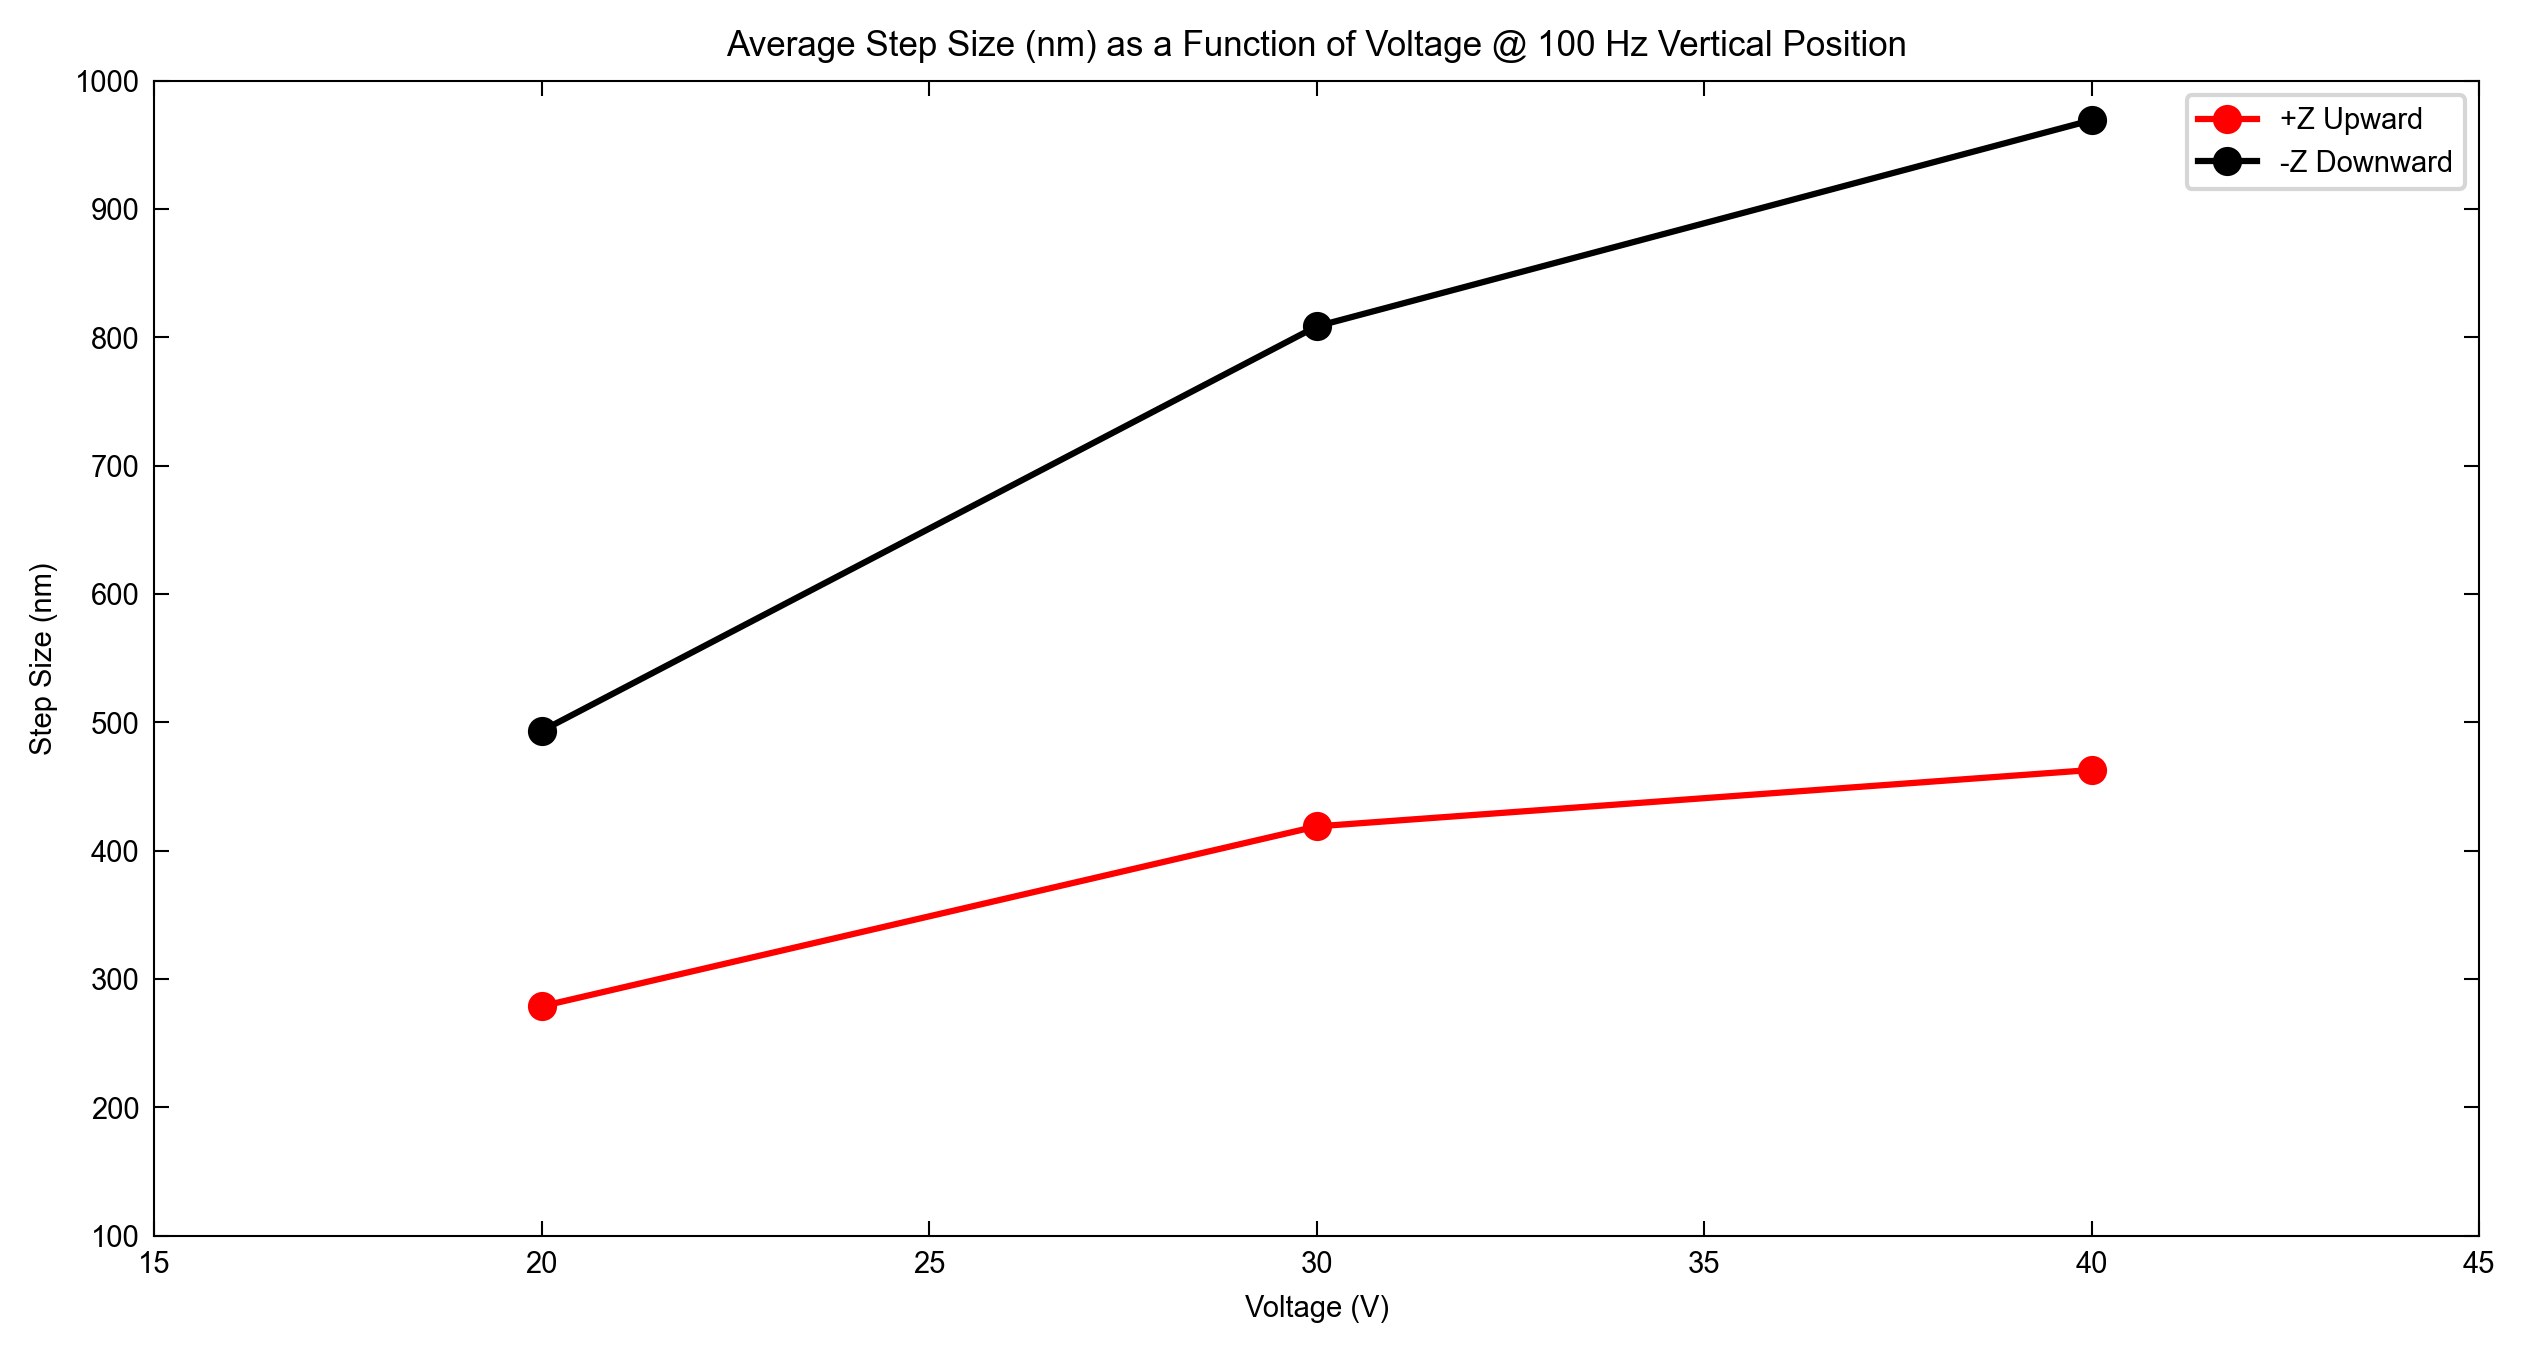

In [11]:
import matplotlib.pyplot as plt

# Data
voltage = [40, 30, 20]
avg_step_plusZ = [462.96, 418.99, 278.81]   # perkiraan dari grafik
avg_step_minusZ = [969.31, 808.63, 493.42]  # perkiraan dari grafik

# Membuat plot
plt.figure(figsize=(10, 5))
plt.plot(voltage, avg_step_plusZ, marker='o', color = 'r', label='+Z Upward')
plt.plot(voltage, avg_step_minusZ, marker='o', color = 'k', label='-Z Downward')

# Memberi judul dan label
plt.title('Average Step Size (nm) as a Function of Voltage @ 100 Hz Vertical Position')
plt.xlabel('Voltage (V)')
plt.ylabel('Step Size (nm)')

# Menampilkan legenda
plt.legend()

# Mengatur sumbu x dan y
plt.xlim(15, 45)
plt.ylim(100, 1000)

# Menampilkan plot
plt.show()


## 6. Correlation Analysis

To summarize the relationships explored above, we compute pairwise
correlations between the swept parameter (Frequency or Voltage) and the
derived metrics (`Step Size`, `Asymmetry`, `Ratio`), separately for each experiment
type.

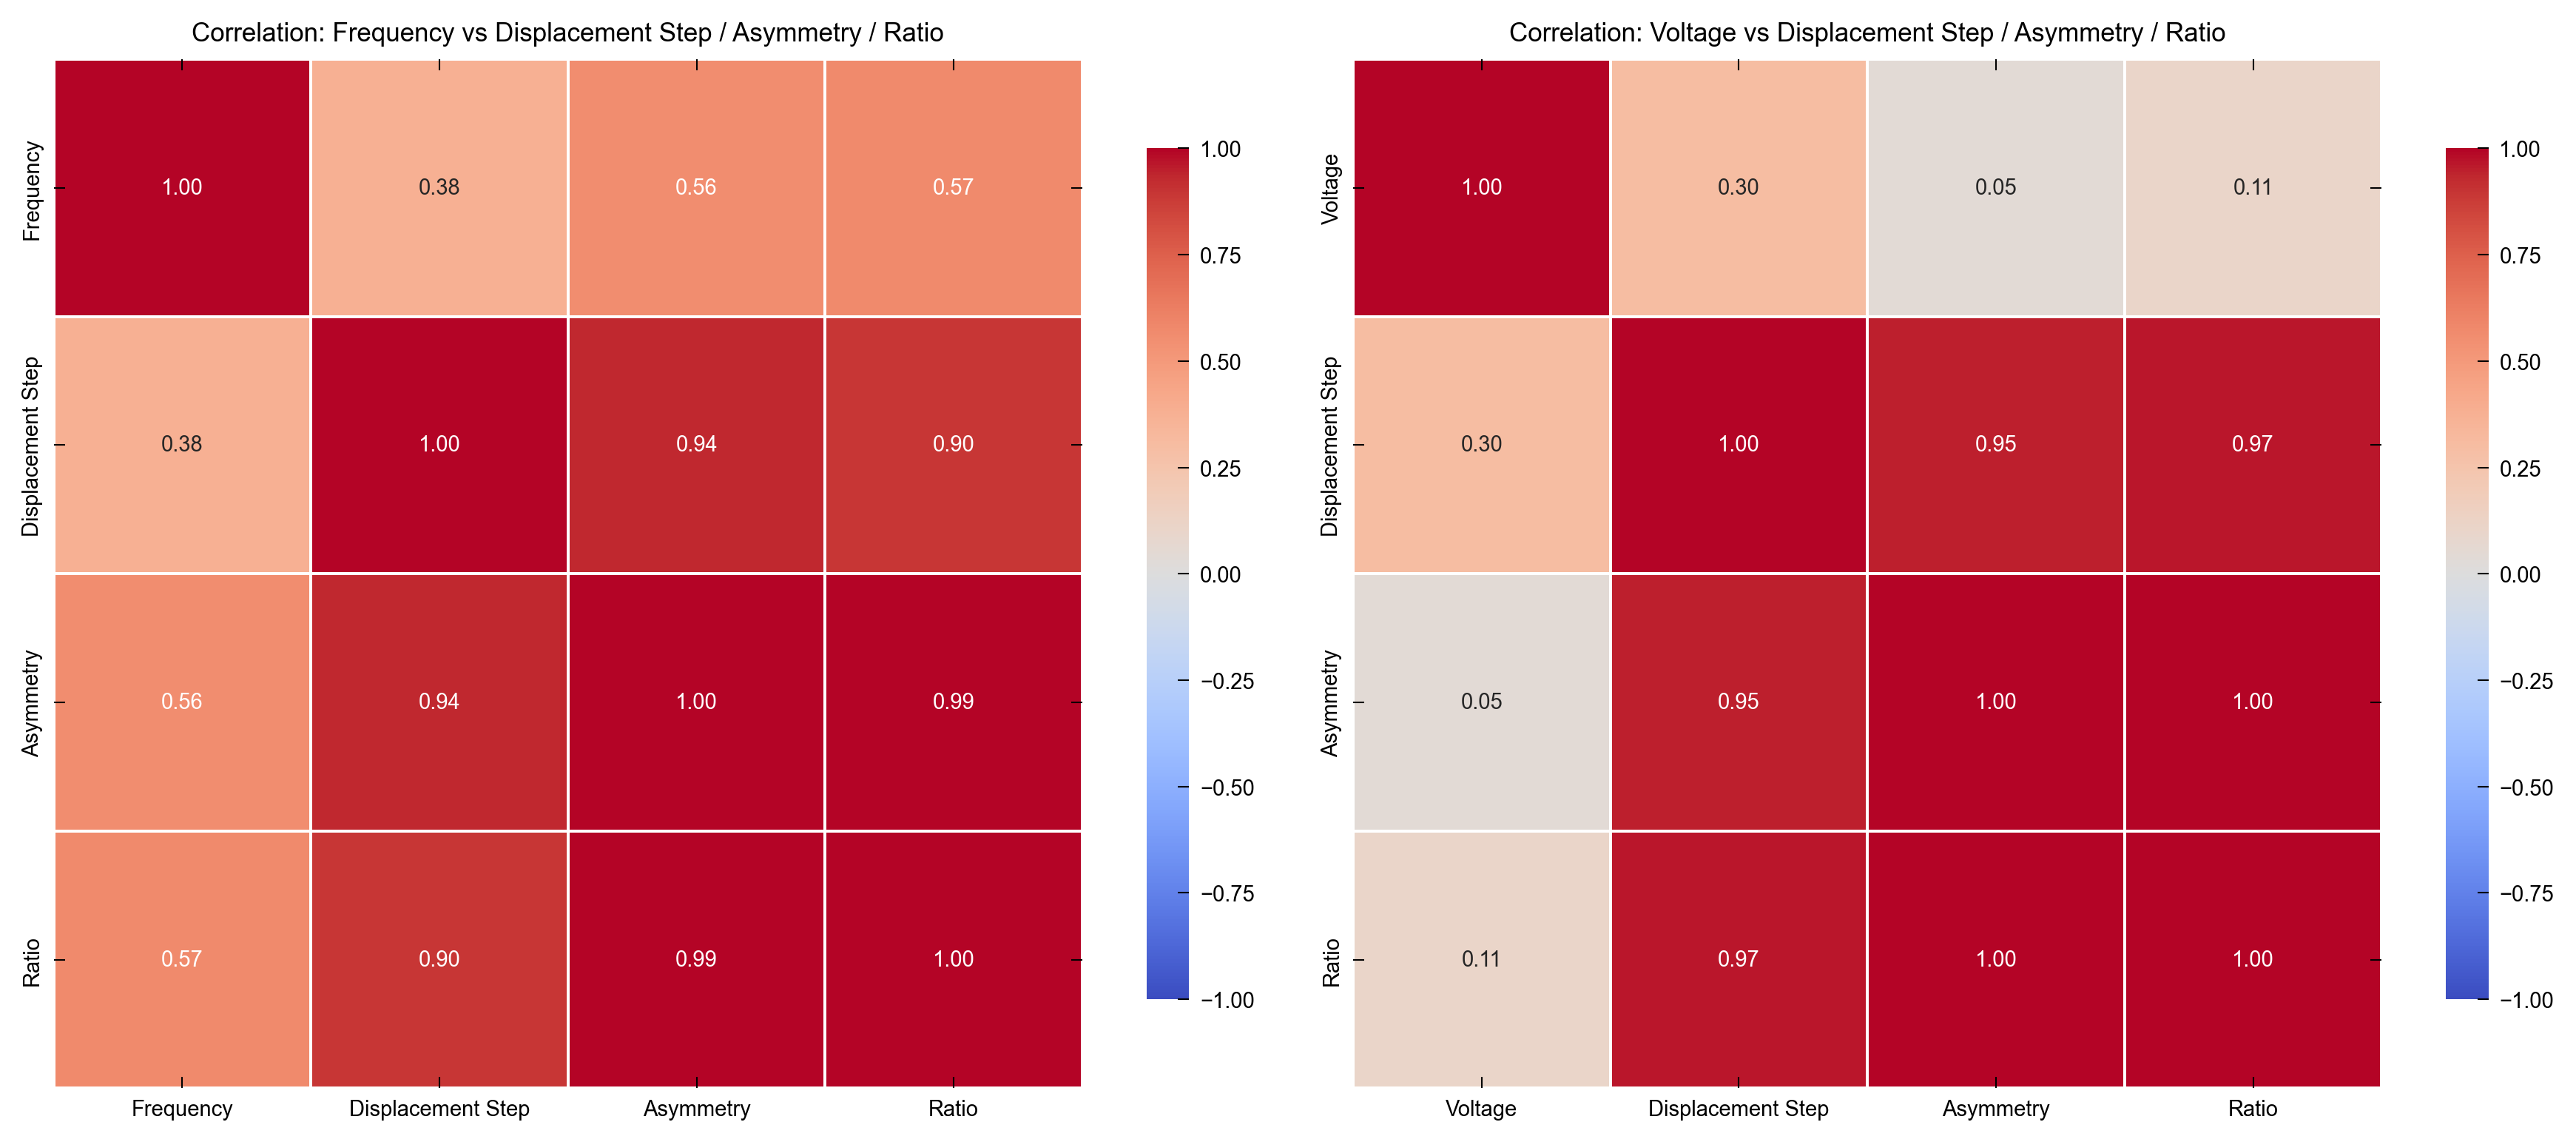

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Rename kolom hanya untuk visualisasi
freq_corr = freq_df[["Frequency", "Ds", "Asymetry", "ratio"]].rename(
    columns={
        "Ds": "Displacement Step",
        "Asymetry": "Asymmetry",
        "ratio": "Ratio"
    }
)

volt_corr = volt_df[["Voltage", "Ds", "Asymetry", "ratio"]].rename(
    columns={
        "Ds": "Displacement Step",
        "Asymetry": "Asymmetry",
        "ratio": "Ratio"
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

corr_freq = freq_corr.corr()
corr_volt = volt_corr.corr()

sns.heatmap(
    corr_freq,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=axes[0],
    cbar_kws={"shrink": 0.8}
)
axes[0].set_title("Correlation: Frequency vs Displacement Step / Asymmetry / Ratio")

sns.heatmap(
    corr_volt,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=axes[1],
    cbar_kws={"shrink": 0.8}
)
axes[1].set_title("Correlation: Voltage vs Displacement Step / Asymmetry / Ratio")

plt.tight_layout()
plt.show()

**Interpretation.** Both heatmaps show a strong positive correlation
between `Step Size`, `Asymmetry`, and `Ratio` the three derived
metrics move together, which makes sense since all three are built from the
same underlying `+Z'` / `-Z'` measurements. The correlation with the swept
parameter itself (Frequency or Voltage) differs in sign between the two
experiments, displacement step increases with frequency but decreases with voltage.


## 7. Distribution of Step Sizes Across Frequency Levels

Finally, we look at the spread of the raw `+Z'` and `-Z'` step-size values
across frequency levels (combining both mounting positions), using a
boxplot overlaid with the individual data points.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23852\2569733864.py:19: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:gray'` for the same effect.

  sns.stripplot(


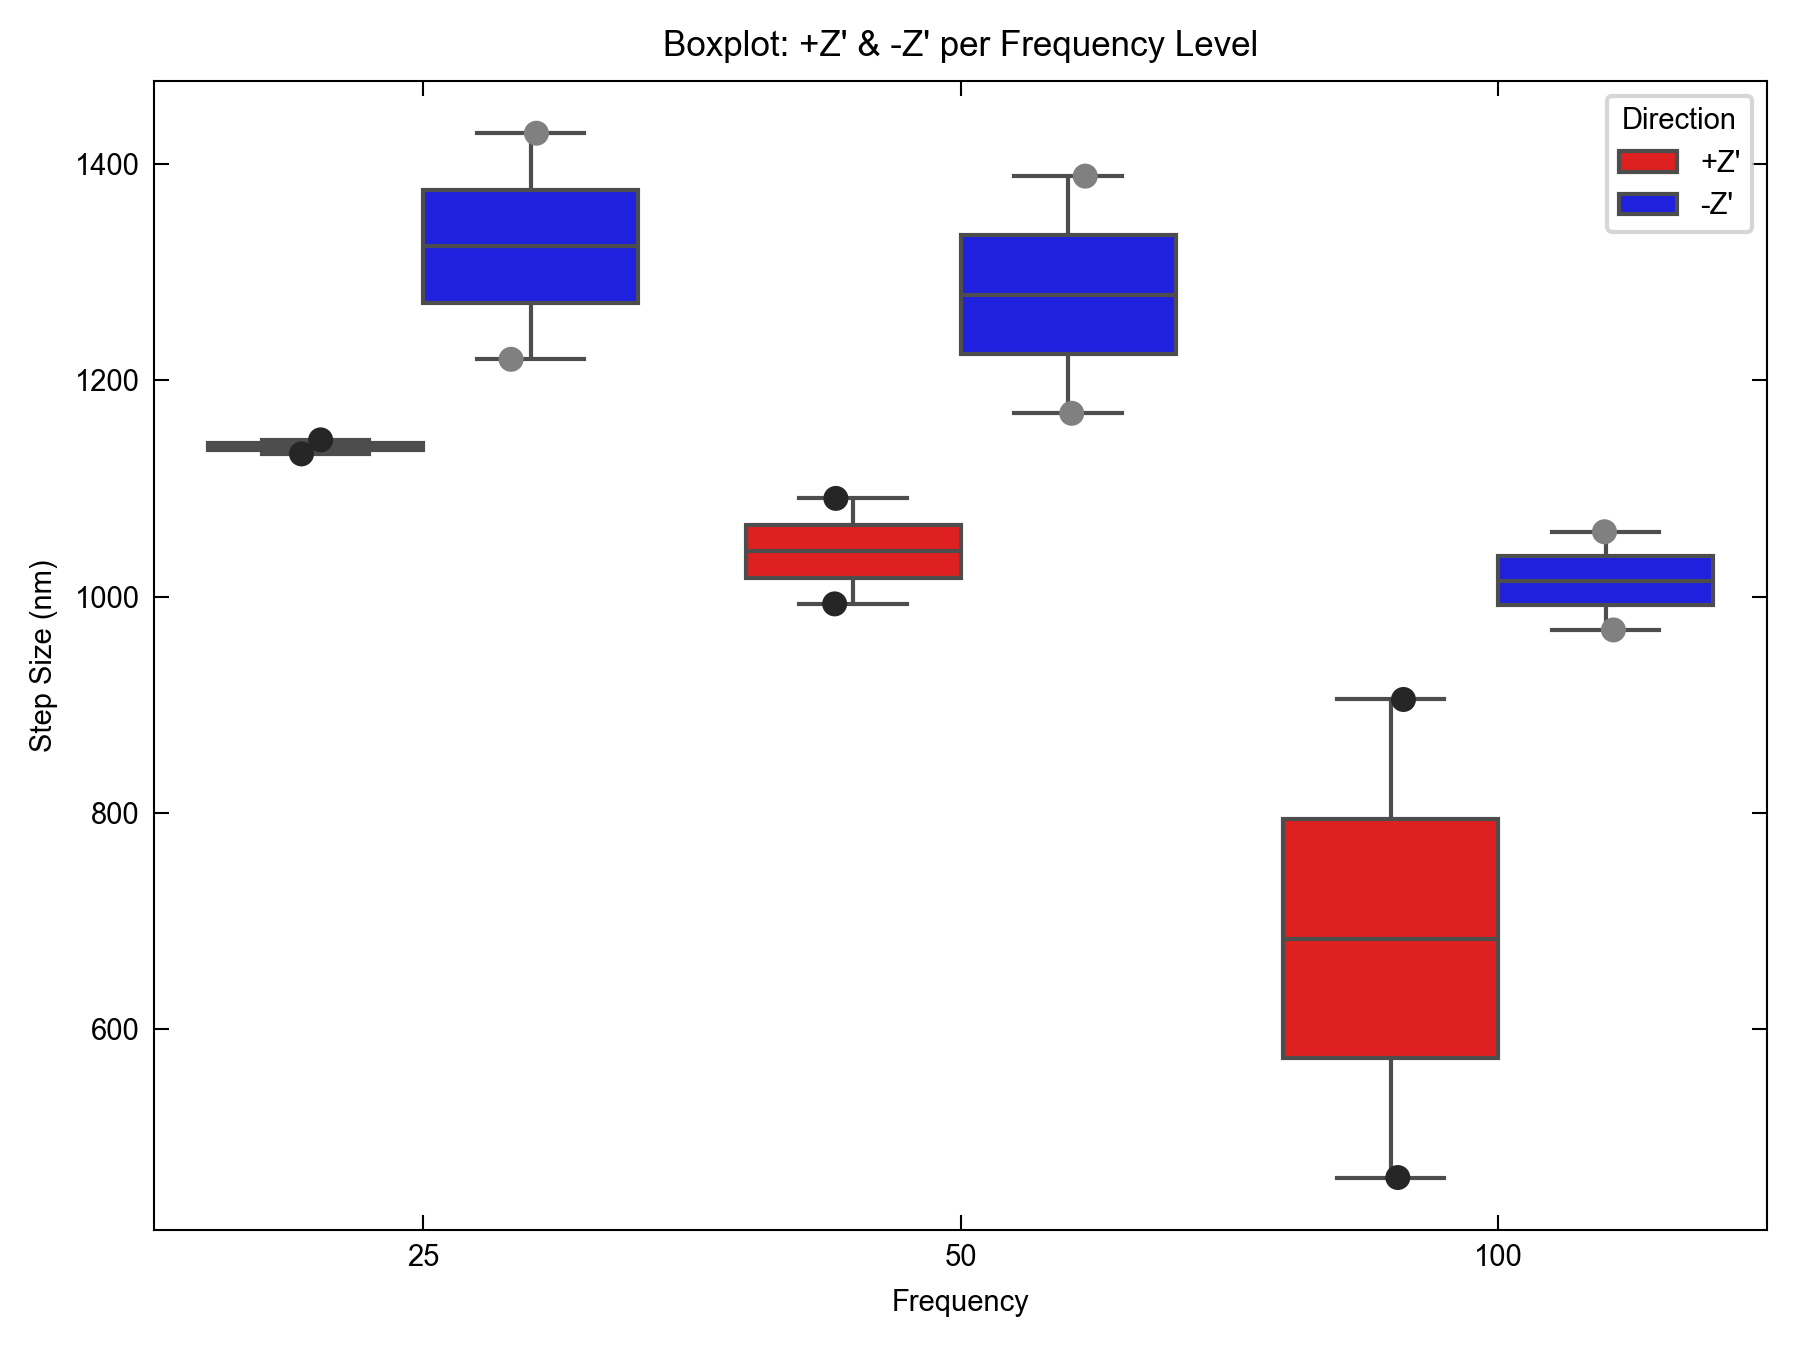

In [13]:
melt_df = freq_df.melt(
    id_vars=["Frequency", "Position"],
    value_vars=["+Z'", "-Z'"],
    var_name="Direction",
    value_name="Step Size (nm)"
)

fig, ax = plt.subplots(figsize=(6, 4.5))

sns.boxplot(
    data=melt_df,
    x="Frequency",
    y="Step Size (nm)",
    hue="Direction",
    palette={"+Z'": "red", "-Z'": "blue"},
    ax=ax
)

sns.stripplot(
    data=melt_df,
    x="Frequency",
    y="Step Size (nm)",
    hue="Direction",
    dodge=True,
    color="gray",
    size=6,
    ax=ax,
    legend=False
)

ax.set_title("Boxplot: +Z' & -Z' per Frequency Level")

plt.tight_layout()
plt.show()

**Interpretation.** The two individual points inside each box correspond to
the Horizontal and Vertical positions, and their separation grows at higher
frequencies, consistent with the increasing vertical-position asymmetry
found earlier.
